# TRAS - C60 Quenched

### Mounting the google drive

In [1]:
# To begin, we import some libraries that we will need later.

# Some handy standard python libraries
import os

# The numpy library is very useful for many things
import numpy as np
import pandas as pd

# The pyplot module from matplotlib will allow us to plot things.
from matplotlib import pyplot as plt
from scipy.optimize import curve_fit
from math import pi

In [2]:
# Connect (mount) your google drive as a virtual directory accessible by this python code.
from google.colab import drive         # Import the python module that allows you to access your google drive
rootpathdrive = '/content/drive'       # This will be the directory as which your google drive will be known
drive.mount(rootpathdrive)             # Now connect to this google drive.

# At first use it will ask you to click on a link, after which you should give permission
# for outside processes to access your google drive. A authorization code is generated which should be entered
#(this is explained in https://colab.research.google.com/notebooks/io.ipynb#scrollTo=XDg9OBaYqRMd).

Mounted at /content/drive


In [3]:
# # A good test to do is if you can see the contents of the directory in which you work on your google drive.
# # Here "My Drive" refers to the "root" of your google drive.
# # By default your notebook should be in a directory called Colab Notebooks.
# # This template assumes all files you want to read in are copied in the
# # same directory. Note the slash at the end of the first line.

# #==============================================================================================================
# #pathTRAS = rootpathdrive+'/'+'My Drive/Year 3 Lab/Pulsar/Crab_pulsar_template/' # Fin's Directory
# #pathTRAS = rootpathdrive+'/'+'My Drive/Year 3 Lab/Pulsar/CrabPulsar/Crab_pulsar_template' #Fin's 2
pathTRAS = rootpathdrive+'/'+'My Drive/Colab Notebooks/TRAS/Pulse_width_experiments/BZbb025_PumpMaxProbeChange' #Sara's directory
# #==============================================================================================================

filelist = []
for (dirpath, dirnames, filenames) in os.walk(pathTRAS):
    filelist.extend(filenames)
    break
print (filelist)   # Show the contents of your working directory. At least your notebook should show up here.


['BZbb1_Probe0_2026-03-17 15-12-34 TA.csv', 'BZbb1_Probe0_2026-03-17 15-12-34 TA.xml', 'BZbb1_Probe1_2026-03-17 15-16-19 TA.xml', 'BZbb1_Probe1_2026-03-17 15-16-19 TA.csv', 'BZbb1_Probe2_2026-03-17 15-21-04 TA.csv', 'BZbb1_Probe2_2026-03-17 15-21-04 TA.xml', 'BZbb1_Probe3_2026-03-17 15-23-39 TA.csv', 'BZbb1_Probe3_2026-03-17 15-23-39 TA.xml', 'BZbb1 Pump_ProbeChange.ipynb']


## Part 5 - Pulse width using ZnTPP samples

**Keeping concentration and repetition rate constant, investigate the effect of varying the
pulse width of the pump and probe lasers on the structure of the TA curve.
Plotted length of spike against increment**

Slope:     -0.0959 ± 0.3279
Intercept: 21.8286 ± 0.6831
Chi²:          10.7089
DOF:           2
Reduced Chi²:  5.3545


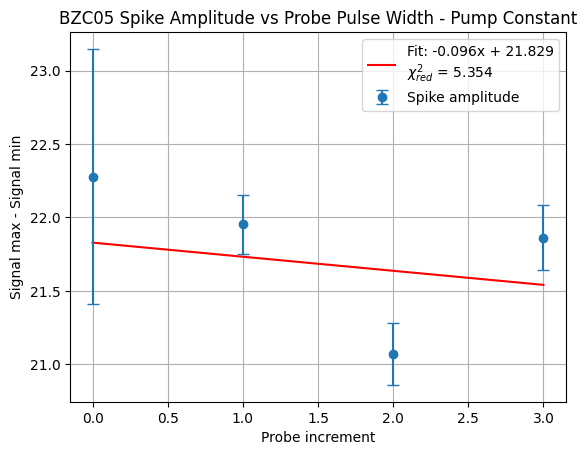

In [4]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re

signal_max_array = []
signal_min_array = []
increment_array  = []
spike_array      = []
error            = []

for file in filelist:
    if not file.endswith(".csv"):
        continue
    if "TA" not in file:
        continue

    csv_title = file

    # ✅ FIX: case-insensitive + optional space
    match = re.search(r"probe\s*(\d+)", csv_title, re.IGNORECASE)
    if not match:
        print(f"Skipping bad filename: {csv_title}")
        continue

    increment = int(match.group(1))

    df = pd.read_csv(
        os.path.join(pathTRAS, csv_title),
        sep=";",
        header=None,
        names=["time", "signal"]
    )

    # Remove first row if it's duplicated header
    df = df.iloc[1:].reset_index(drop=True)

    # Safer conversion
    df = df.apply(pd.to_numeric, errors='coerce')
    df = df.dropna()

    signal = df["signal"].to_numpy()

    # Background region
    df_bg = df[df["time"] < -10]
    if len(df_bg) == 0:
        print(f"No background data in {csv_title}, skipping")
        continue

    bg_signal = df_bg["signal"].to_numpy()

    signal_min   = np.mean(bg_signal)
    signal_max   = np.max(signal)
    signal_error = np.std(bg_signal)

    error.append(signal_error)
    signal_max_array.append(signal_max)
    signal_min_array.append(signal_min)

    spike_length = signal_max - signal_min
    spike_array.append(spike_length)
    increment_array.append(increment)

if len(increment_array) == 0:
    raise ValueError("No valid files processed — check filename pattern.")

# ── Sort together ───────────────────────────────────────────────────────────
data = sorted(zip(increment_array, spike_array, error))
increment_array, spike_array, error = zip(*data)

increment_array = np.array(increment_array, dtype=float)
spike_array     = np.array(spike_array,     dtype=float)
error           = np.array(error,           dtype=float)

# Avoid divide-by-zero
error[error == 0] = np.min(error[error > 0])

# ── Weighted linear fit ─────────────────────────────────────────────────────
weights       = 1 / error
coeff, cov    = np.polyfit(increment_array, spike_array, 1, w=weights, cov=True)
slope         = coeff[0]
intercept     = coeff[1]
slope_err     = np.sqrt(cov[0, 0])
intercept_err = np.sqrt(cov[1, 1])

print(f"Slope:     {slope:.4f} ± {slope_err:.4f}")
print(f"Intercept: {intercept:.4f} ± {intercept_err:.4f}")

# ── Chi-squared ─────────────────────────────────────────────────────────────
y_pred    = slope * increment_array + intercept
residuals = spike_array - y_pred
chi2      = np.sum((residuals / error) ** 2)
dof       = len(spike_array) - 2
chi2_red  = chi2 / dof

print(f"Chi²:          {chi2:.4f}")
print(f"DOF:           {dof}")
print(f"Reduced Chi²:  {chi2_red:.4f}")

# ── Plot ────────────────────────────────────────────────────────────────────
x_fit = np.linspace(increment_array.min(), increment_array.max(), 200)
y_fit = slope * x_fit + intercept

plt.errorbar(increment_array, spike_array, yerr=error,
             fmt='o', capsize=4, label="Spike amplitude", zorder=3)

plt.plot(x_fit, y_fit, 'r-',
         label=f"Fit: {slope:.3f}x + {intercept:.3f}\n$\\chi^2_{{red}}$ = {chi2_red:.3f}")

plt.xlabel("Probe increment")  # ✅ corrected label
plt.ylabel("Signal max - Signal min")
plt.title("BZC05 Spike Amplitude vs Probe Pulse Width - Pump Constant")

plt.legend()
plt.grid(True)

plt.savefig(
    os.path.join(pathTRAS, "BZbb1_PumpMaxx_ProbeChange.png"),
    dpi=300, bbox_inches="tight"
)

plt.show()

probe_0: A = 19.5329 ± 0.2241,  τ = 975.14 ± 15.72 ns,  σ_IRF = 54.84 ns


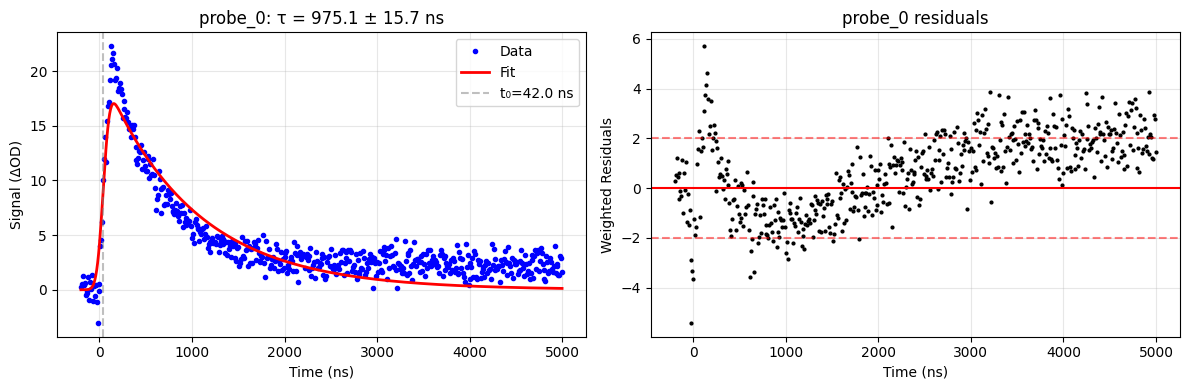

probe_1: A = 19.6702 ± 0.0463,  τ = 987.86 ± 3.27 ns,  σ_IRF = 54.89 ns


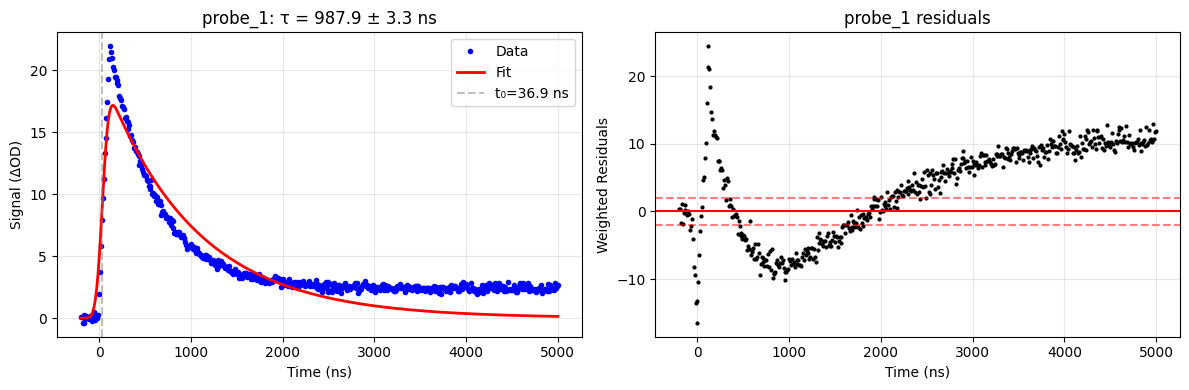

probe_2: A = 19.1536 ± 0.0445,  τ = 970.87 ± 3.17 ns,  σ_IRF = 54.95 ns


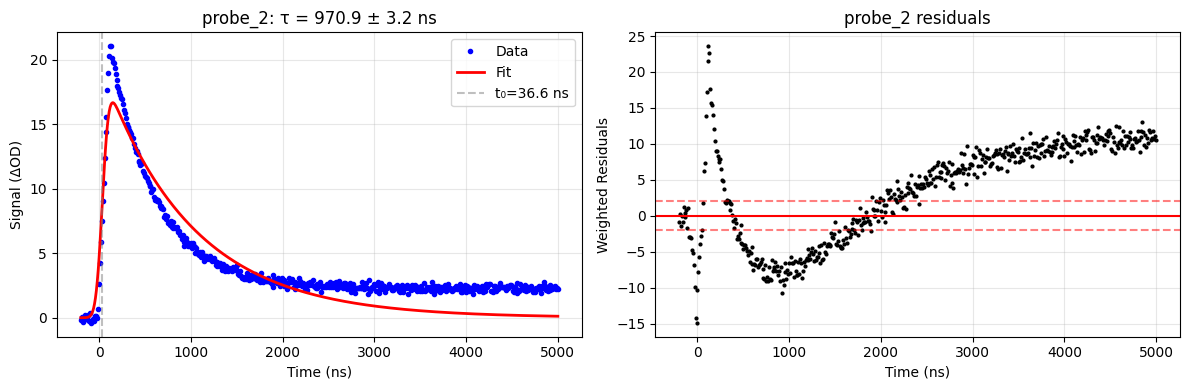

probe_3: A = 19.4662 ± 0.0424,  τ = 989.16 ± 3.02 ns,  σ_IRF = 55.04 ns


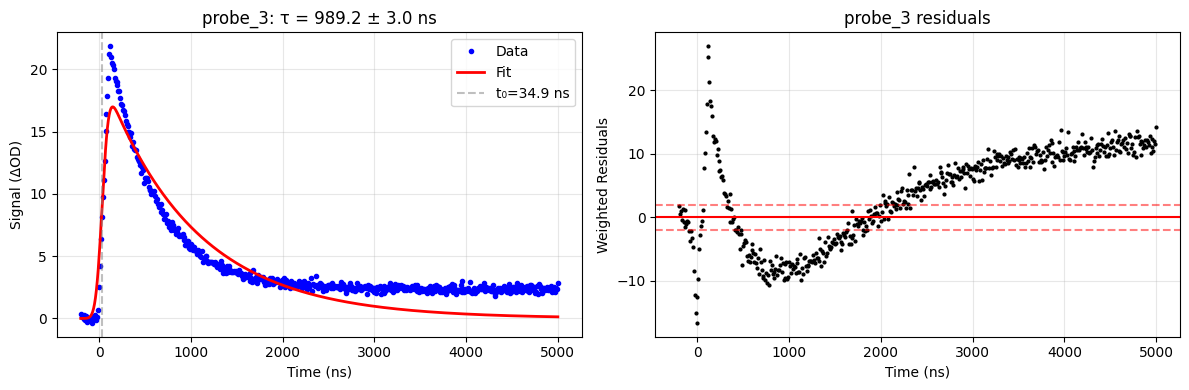


Weighted mean τ = 982.6 ± 1.8 ns
Weighted mean A = 19.4265 ± 0.0254


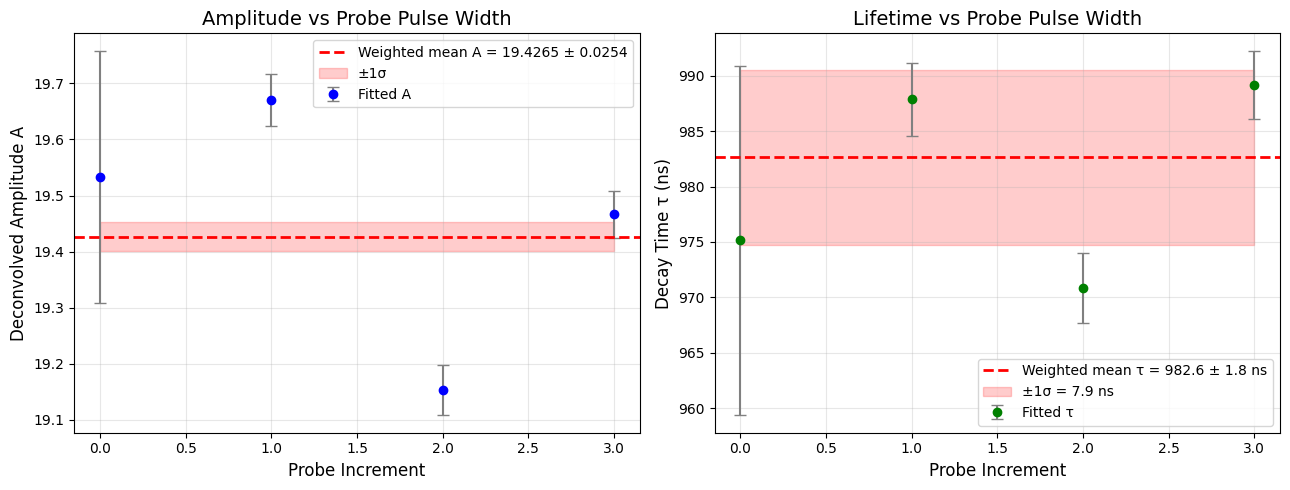

In [5]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re
from scipy.optimize import curve_fit
from scipy.special import erfc
from scipy import stats
# ── Constants ─────────────────────────────────────────────────────────────────
NS_PER_INCREMENT = (39 - 6) / 15    # probe spans 6–39 ns over 0–15 increments
FWHM_TO_SIGMA    = 1 / 2.355
PUMP_FWHM        = 129.0            # pump fixed at max throughout
BASE_PROBE_FWHM  = 6.0              # probe at increment 0

def analytical_model(t, A, tau, t0, sigma_irf):
    tau       = max(tau, 1e-6)
    sigma_irf = max(sigma_irf, 1e-6)
    sigma2    = sigma_irf ** 2
    term1     = sigma2 / (2 * tau**2) - (t - t0) / tau
    arg       = (sigma2 / tau - (t - t0)) / (np.sqrt(2) * sigma_irf)
    return (A / 2) * np.exp(term1) * erfc(arg)

def estimate_measurement_error(signal, window_size=5):
    return max(np.std(signal[:min(window_size, len(signal))]), 1e-6)

def get_initial_guesses(t, signal, sigma_irf):
    peak_idx        = np.argmax(signal)
    t0_guess        = t[peak_idx]
    tau_guess_init  = 860.0
    A_guess         = signal[peak_idx] * np.exp(sigma_irf**2 / (2 * tau_guess_init**2))
    tail_start_idx  = np.searchsorted(t, t0_guess + 3 * sigma_irf)
    if tail_start_idx + 5 < len(t):
        tail_t      = t[tail_start_idx:]
        log_signal  = np.log(np.maximum(signal[tail_start_idx:], 1e-10))
        if len(tail_t) > 3:
            coeffs    = np.polyfit(tail_t - tail_t[0], log_signal, 1)
            tau_guess = -1 / coeffs[0] if coeffs[0] < 0 else tau_guess_init
        else:
            tau_guess = tau_guess_init
    else:
        tau_guess = tau_guess_init
    return A_guess, tau_guess, t0_guess

def parse_increment(filename):
    fname = os.path.basename(filename).lower()
    m = re.search(r"probe(\d+)", fname)  # handles both "Probe0" and "probe 0"
    if m:
        increment = int(m.group(1))
        return increment, f"probe_{increment}"
    return None, "unknown"
# ── Main Loop ─────────────────────────────────────────────────────────────────
increment_array  = []
A_array          = []
tau_array        = []
A_err_array      = []
tau_err_array    = []

for file in sorted(filelist):
    if not (file.endswith(".csv") and "TA" in file):
        continue

    increment, label = parse_increment(file)
    if increment is None:
        print(f"Skipping {file} ({label})")
        continue

    df = pd.read_csv(
        os.path.join(pathTRAS, file),
        sep=";", header=None, names=["time", "signal"]
    )
    df = df.iloc[1:].reset_index(drop=True).astype(float)

    bg_mask  = df["time"] < -10
    bg_mean  = df[bg_mask]["signal"].mean() if bg_mask.sum() > 0 else df["signal"].iloc[:10].mean()
    df_roi   = df[df["time"] >= -200].copy()
    df_roi["signal_corr"] = df_roi["signal"] - bg_mean

    time_data   = df_roi["time"].to_numpy()
    signal_data = df_roi["signal_corr"].to_numpy()

    pre_trigger = time_data < -10
    measurement_error = np.std(signal_data[pre_trigger]) if pre_trigger.sum() > 5 \
                        else estimate_measurement_error(signal_data)
    measurement_error = max(measurement_error, 1e-6)

    pump_sigma  = PUMP_FWHM * FWHM_TO_SIGMA
    probe_sigma = (BASE_PROBE_FWHM + increment * NS_PER_INCREMENT) * FWHM_TO_SIGMA
    sigma_irf   = np.sqrt(pump_sigma**2 + probe_sigma**2)

    def model_fixed_irf(t, A, tau, t0):
        return analytical_model(t, A, tau, t0, sigma_irf)

    A_guess, tau_guess, t0_guess = get_initial_guesses(time_data, signal_data, sigma_irf)

    try:
        popt, pcov = curve_fit(
            model_fixed_irf, time_data, signal_data,
            p0=[A_guess, tau_guess, t0_guess],
            bounds=([0, 10, time_data[0]], [np.inf, 5000, time_data[-1]]),
            maxfev=10000,
            sigma=measurement_error * np.ones_like(signal_data),
            absolute_sigma=True
        )
        perr              = np.sqrt(np.diag(pcov))
        A_fit, tau_fit, t0_fit = popt

        print(f"{label}: A = {A_fit:.4f} ± {perr[0]:.4f},  "
              f"τ = {tau_fit:.2f} ± {perr[1]:.2f} ns,  "
              f"σ_IRF = {sigma_irf:.2f} ns")

        # Per-file trace plot
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
        ax1.plot(time_data, signal_data, 'bo', markersize=3, label='Data')
        ax1.plot(time_data, model_fixed_irf(time_data, *popt), 'r-', lw=2, label='Fit')
        ax1.axvline(t0_fit, color='gray', linestyle='--', alpha=0.5, label=f't₀={t0_fit:.1f} ns')
        ax1.set_xlabel('Time (ns)'); ax1.set_ylabel('Signal (ΔOD)')
        ax1.set_title(f'{label}: τ = {tau_fit:.1f} ± {perr[1]:.1f} ns')
        ax1.legend(); ax1.grid(True, alpha=0.3)

        residuals = signal_data - model_fixed_irf(time_data, *popt)
        ax2.plot(time_data, residuals / measurement_error, 'ko', markersize=2)
        ax2.axhline(0, color='r')
        ax2.axhline( 2, color='r', linestyle='--', alpha=0.5)
        ax2.axhline(-2, color='r', linestyle='--', alpha=0.5)
        ax2.set_xlabel('Time (ns)'); ax2.set_ylabel('Weighted Residuals')
        ax2.set_title(f'{label} residuals')
        ax2.grid(True, alpha=0.3)
        plt.tight_layout(); plt.show()

        increment_array.append(increment)
        A_array.append(A_fit)
        tau_array.append(tau_fit)
        A_err_array.append(perr[0])
        tau_err_array.append(perr[1])

    except (RuntimeError, ValueError) as e:
        print(f"{label}: fit failed — {e}")
        continue

# ── Arrays ────────────────────────────────────────────────────────────────────
increment_array = np.array(increment_array)
A_array         = np.array(A_array)
tau_array       = np.array(tau_array)
A_err_array     = np.array(A_err_array)
tau_err_array   = np.array(tau_err_array)

# ── Summary ───────────────────────────────────────────────────────────────────
tau_weighted_mean = np.average(tau_array, weights=1/tau_err_array**2)
tau_weighted_std  = np.sqrt(1 / np.sum(1/tau_err_array**2))
A_weighted_mean   = np.average(A_array,   weights=1/A_err_array**2)
A_weighted_std    = np.sqrt(1 / np.sum(1/A_err_array**2))
tau_std           = np.std(tau_array)

print(f"\nWeighted mean τ = {tau_weighted_mean:.1f} ± {tau_weighted_std:.1f} ns")
print(f"Weighted mean A = {A_weighted_mean:.4f} ± {A_weighted_std:.4f}")

# ── Summary Plot ──────────────────────────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

# Amplitude — horizontal line fit (weighted mean)
ax1.errorbar(increment_array, A_array, yerr=A_err_array,
             fmt='o', capsize=4, markersize=6, color='blue', ecolor='gray', label='Fitted A')
ax1.axhline(A_weighted_mean, color='red', linestyle='--', linewidth=2,
            label=f'Weighted mean A = {A_weighted_mean:.4f} ± {A_weighted_std:.4f}')
ax1.fill_between(increment_array,
                 A_weighted_mean - A_weighted_std,
                 A_weighted_mean + A_weighted_std,
                 alpha=0.2, color='red', label='±1σ')
ax1.set_xlabel("Probe Increment", fontsize=12)
ax1.set_ylabel("Deconvolved Amplitude A", fontsize=12)
ax1.set_title("Amplitude vs Probe Pulse Width", fontsize=14)
ax1.legend(); ax1.grid(True, alpha=0.3)

# Lifetime — horizontal line fit (weighted mean)
ax2.errorbar(increment_array, tau_array, yerr=tau_err_array,
             fmt='o', capsize=4, markersize=6, color='green', ecolor='gray', label='Fitted τ')
ax2.axhline(tau_weighted_mean, color='red', linestyle='--', linewidth=2,
            label=f'Weighted mean τ = {tau_weighted_mean:.1f} ± {tau_weighted_std:.1f} ns')
ax2.fill_between(increment_array,
                 tau_weighted_mean - tau_std,
                 tau_weighted_mean + tau_std,
                 alpha=0.2, color='red', label=f'±1σ = {tau_std:.1f} ns')
ax2.set_xlabel("Probe Increment", fontsize=12)
ax2.set_ylabel("Decay Time τ (ns)", fontsize=12)
ax2.set_title("Lifetime vs Probe Pulse Width", fontsize=14)
ax2.legend(); ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("TRAS_ProbeVariation_Analysis.png", dpi=300, bbox_inches="tight")
plt.show()